## Import

In [1]:
from utils import *
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

Traning models ...


## Parameters

In [2]:
target_column = "AMZN"
input_days= 30
output_days= [1, 7, 14]
test_size=0.2
shuffle=True

## Load dataset

In [3]:
data = read_and_clean_data(file_path = "./dataset/portfolio_data.csv", drop_list = ["DPZ", "BTC", "NFLX"])

Loading the data...
Data shape: (1520, 2)
Null values: Date    0
AMZN    0
dtype: int64
Duplicate rows: 0
Load data completed.
Make sure date items are datetime


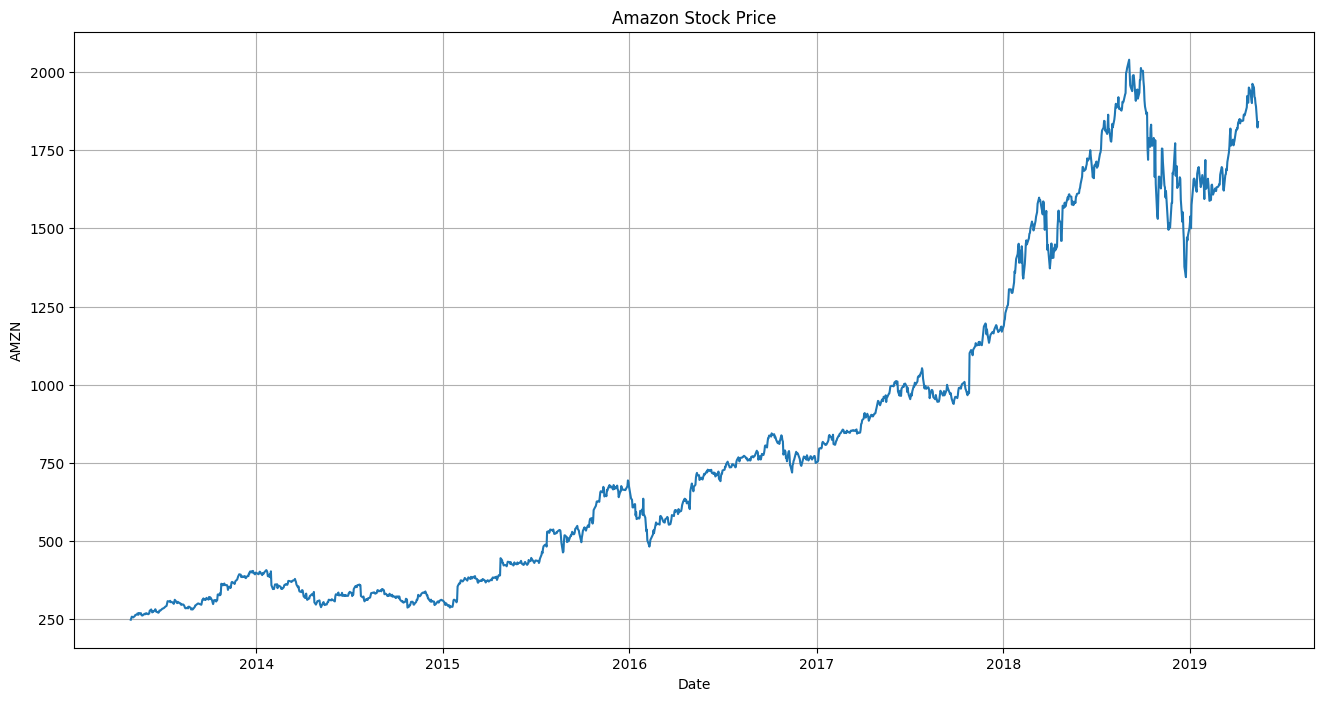

In [4]:
plot_data(data, "Amazon Stock Price", "Date", "AMZN")

### Generate Sliding Windows

In [5]:
selected_value = data[target_column].values
window_data = {}
for item in output_days:
    X, y = generate_sliding_windows(
        selected_value,
        input_days,
        item
        )
    window_data[item] = {
        "X" : X,
        "y" : y
    }


 Expected generated data length should be: 1490
x_start_index: 0 - x_end_index: 29 - y_start_index: 30 - y_end_index: 31
x_start_index: 1 - x_end_index: 30 - y_start_index: 31 - y_end_index: 32
x_start_index: 2 - x_end_index: 31 - y_start_index: 32 - y_end_index: 33
x_start_index: 3 - x_end_index: 32 - y_start_index: 33 - y_end_index: 34
x_start_index: 4 - x_end_index: 33 - y_start_index: 34 - y_end_index: 35
x_start_index: 5 - x_end_index: 34 - y_start_index: 35 - y_end_index: 36
x_start_index: 6 - x_end_index: 35 - y_start_index: 36 - y_end_index: 37
x_start_index: 7 - x_end_index: 36 - y_start_index: 37 - y_end_index: 38
x_start_index: 8 - x_end_index: 37 - y_start_index: 38 - y_end_index: 39

 Expected generated data length should be: 1484
x_start_index: 0 - x_end_index: 29 - y_start_index: 30 - y_end_index: 37
x_start_index: 1 - x_end_index: 30 - y_start_index: 31 - y_end_index: 38
x_start_index: 2 - x_end_index: 31 - y_start_index: 32 - y_end_index: 39
x_start_index: 3 - x_end_i

In [6]:
# window_output[1]["X"]

### Train / Test Split

In [ ]:
train_test_data = {}

for day in output_days:
    X = window_data[day]["X"]
    y = window_data[day]["y"]

    X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size= test_size,
            shuffle= shuffle
        )
    train_test_data[day] = {
            "X_train" : X_train,
            "X_test" : X_test,
            "y_train" : y_train,
            "y_test" : y_test
            }

In [ ]:
# print(train_test_data)
# print(train_test_data.keys)
# print(output_days)

{1: {'X_train': array([[1511.97998 , 1512.449951, 1493.449951, ..., 1405.22998 ,
        1406.079956, 1436.219971],
       [ 948.950012,  947.619995,  961.349976, ...,  995.169983,
         992.590027, 1002.22998 ],
       [ 384.609985,  382.720001,  387.829987, ...,  382.649994,
         382.359985,  385.109985],
       ...,
       [1405.22998 , 1406.079956, 1436.219971, ..., 1576.119995,
        1587.280029, 1581.76001 ],
       [ 310.890015,  310.700012,  306.399994, ...,  364.940002,
         362.570007,  368.920013],
       [ 964.169983,  987.710022,  995.169983, ..., 1039.869995,
        1052.800049, 1046.      ]], shape=(1192, 30)), 'X_test': array([[ 517.539978,  516.890015,  522.23999 , ...,  562.440002,
         570.76001 ,  573.150024],
       [1802.      , 1829.23999 , 1863.609985, ..., 1998.099976,
        2002.380005, 2012.709961],
       [ 848.059998,  847.380005,  845.609985, ...,  948.22998 ,
         946.940002,  941.030029],
       ...,
       [ 713.22998 ,  717.9299

### Data Scaling

In [9]:
scaled_data = {}
print("Start")
for day in train_test_data:
    
    X_train_norm, X_test_norm, y_train_norm, y_test_norm, target_scaler = scale_data(
        train_test_data[day]["X_train"],
        train_test_data[day]["X_test"],
        train_test_data[day]["y_train"],
        train_test_data[day]["y_test"]
    )
    print(f"day- {day}")
    print(f"X_train Shape: {X_train_norm.shape} - X_test Shape: {X_test_norm.shape}")
    print(f"y_train Shape: {y_train_norm.shape} - y_test Shape: {y_test_norm.shape}")

    scaled_data[day] = {
        "X_train_norm" : X_train_norm,
        "X_test_norm" : X_test_norm,
        "y_train_norm" : y_train_norm,
        "y_test_norm" : y_test_norm,
        "target_scaler" : target_scaler
        }
    # print(scaled_data[day]["X_train_norm"])
    # print(scaled_data[day]["y_train_norm"])

Start
day- 1
X_train Shape: (1192, 30) - X_test Shape: (298, 30)
y_train Shape: (1192, 1) - y_test Shape: (298, 1)
day- 7
X_train Shape: (1187, 30) - X_test Shape: (297, 30)
y_train Shape: (1187, 7) - y_test Shape: (297, 7)
day- 14
X_train Shape: (1181, 30) - X_test Shape: (296, 30)
y_train Shape: (1181, 14) - y_test Shape: (296, 14)


### Training Regression Models

In [10]:
linear_models = {}
knn_models = {}
decision_tree_models = {}
random_forest_models = {}
mlp_models = {}

for day in output_days:
    X_train = scaled_data[day]["X_train_norm"]
    y_train = scaled_data[day]["y_train_norm"]

    linear_models[day] = train_model(
        LinearRegression(),
        X_train,
        y_train
        )
    knn_models[day] = train_model(
        KNeighborsRegressor(),
        X_train,
        y_train
        )
    decision_tree_models[day] = train_model(
        DecisionTreeRegressor(),
        X_train,
        y_train
        )
    random_forest_models[day] = train_model(
        RandomForestRegressor(),
        X_train,
        y_train
        )
    mlp_models[day] = train_model(
        MLPRegressor(),
        X_train,
        y_train
    )

e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1775: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


##### Regression Model Predictions

In [11]:
linear_predictions = {}
knn_predictions = {}
decision_tree_predictions = {}
random_forest_predictions = {}
mlp_predictions = {}

for day in output_days:

    linear_predictions[day] = predict_model(
        linear_models[day],
        scaled_data[day]["X_test_norm"]
    )
    knn_predictions[day] = predict_model(
        knn_models[day],
        scaled_data[day]["X_test_norm"]
    )
    decision_tree_predictions[day] = predict_model(
        decision_tree_models[day],
        scaled_data[day]["X_test_norm"]
    )
    random_forest_predictions[day] = predict_model(
        random_forest_models[day],
        scaled_data[day]["X_test_norm"]
    )
    mlp_predictions[day] = predict_model(
        mlp_models[day],
        scaled_data[day]["X_test_norm"]
        )

##### Inverse Data

In [12]:
linear_predictions_real = {}
knn_predictions_real = {}
decision_tree_predictions_real = {}
random_forest_predictions_real = {}
mlp_predictions_real = {}

y_test_real = {}

for day in output_days:
    target_scaler = scaled_data[day]["target_scaler"]

    linear_predictions_real[day] = inverse_transform_data(
        target_scaler,
        linear_predictions[day]
    )
    knn_predictions_real[day] = inverse_transform_data(
        target_scaler,
        knn_predictions[day]
    )
    decision_tree_predictions_real[day] = inverse_transform_data(
        target_scaler,
        decision_tree_predictions[day]
    )
    random_forest_predictions_real[day] = inverse_transform_data(
        target_scaler,
        random_forest_predictions[day]
    )
    mlp_predictions_real[day] = inverse_transform_data(
        target_scaler,
        mlp_predictions[day]
    )
    y_test_real[day] = inverse_transform_data(
        target_scaler,
        scaled_data[day]["y_test_norm"]
    )

##### MAE / RMSE

In [ ]:
#Test
for day in output_days:
    print(f"\nDay: {day}")
    print("X_test:",
          scaled_data[day]["X_test_norm"].shape)
    print("y_test:",
          scaled_data[day]["y_test_norm"].shape)
    print("target_scaler:",
          scaled_data[day]["target_scaler"].n_features_in_)


Day: 1
X_test: (298, 30)
y_test: (298, 1)
target_scaler: 1

Day: 7
X_test: (297, 30)
y_test: (297, 7)
target_scaler: 7

Day: 14
X_test: (296, 30)
y_test: (296, 14)
target_scaler: 14


In [14]:
results = {}
for day in output_days:
    y_test = y_test_real[day]

    predictions_models = {
        "Linear": linear_predictions_real[day],
        "KNN": knn_predictions_real[day],
        "Decision-T": decision_tree_predictions_real[day],
        "Random-F": random_forest_predictions_real[day],
        "ANN": mlp_predictions_real[day]
    }
    print(f"Day: {day}")
    print("y_test:", y_test.shape)

    for name, prediction in predictions_models.items():
        print(name, prediction.shape)

    results[day] = evaluate_models(
        y_test,
        predictions_models
    )

Day: 1
y_test: (298, 1)
Linear (298, 1)
KNN (298, 1)
Decision-T (298, 1)
Random-F (298, 1)
ANN (298, 1)
Day: 7
y_test: (297, 7)
Linear (297, 7)
KNN (297, 7)
Decision-T (297, 7)
Random-F (297, 7)
ANN (297, 7)
Day: 14
y_test: (296, 14)
Linear (296, 14)
KNN (296, 14)
Decision-T (296, 14)
Random-F (296, 14)
ANN (296, 14)


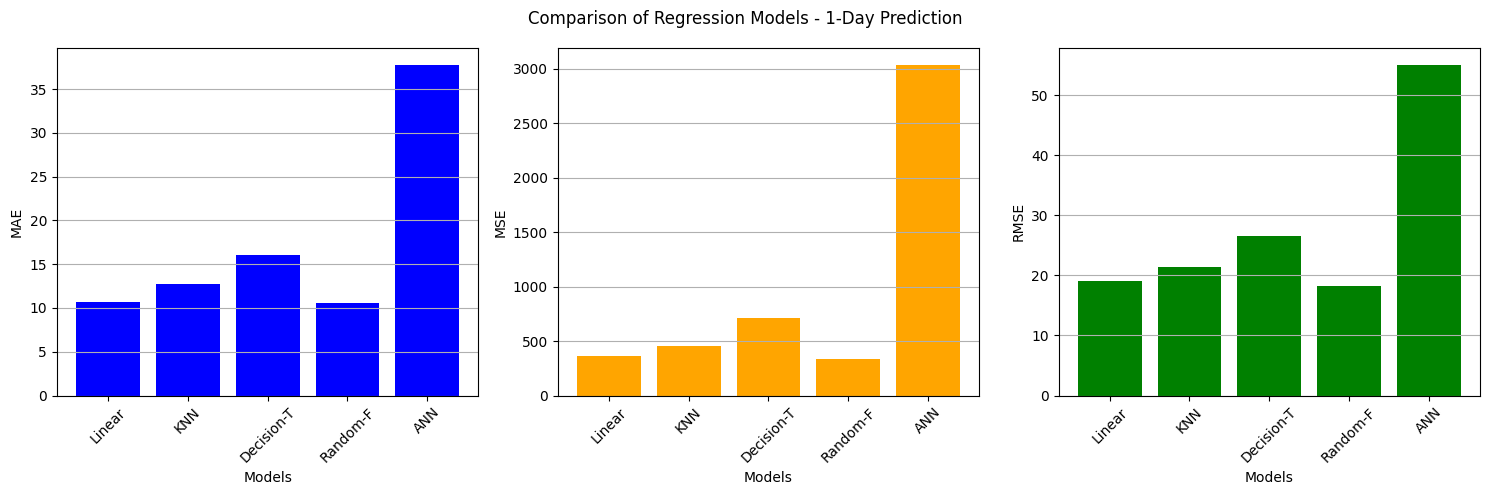

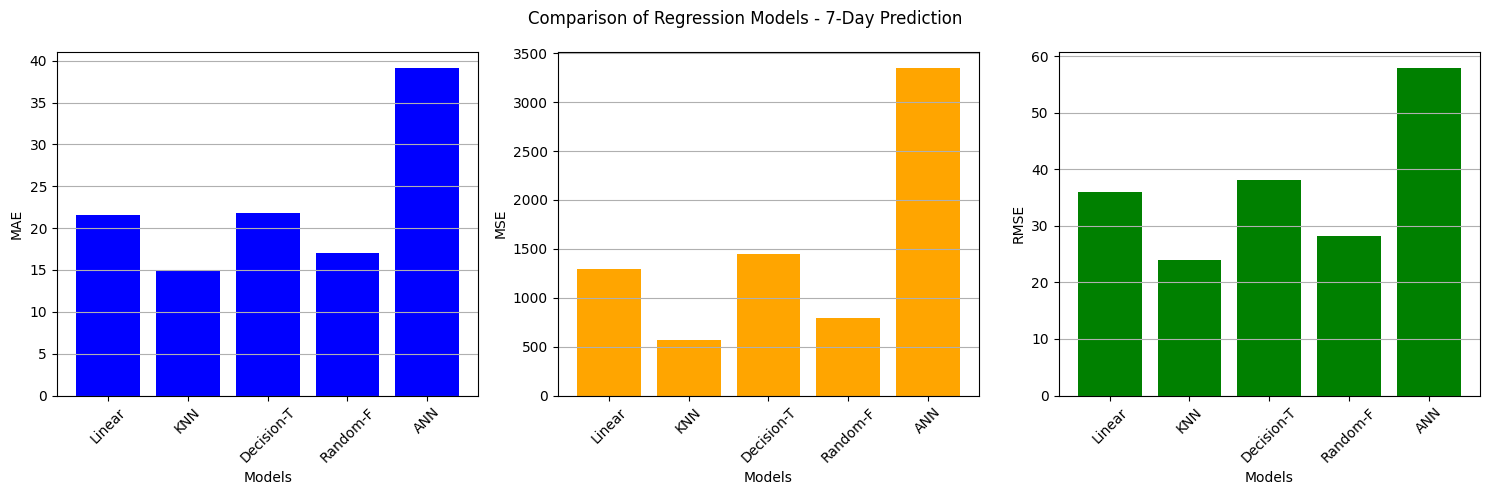

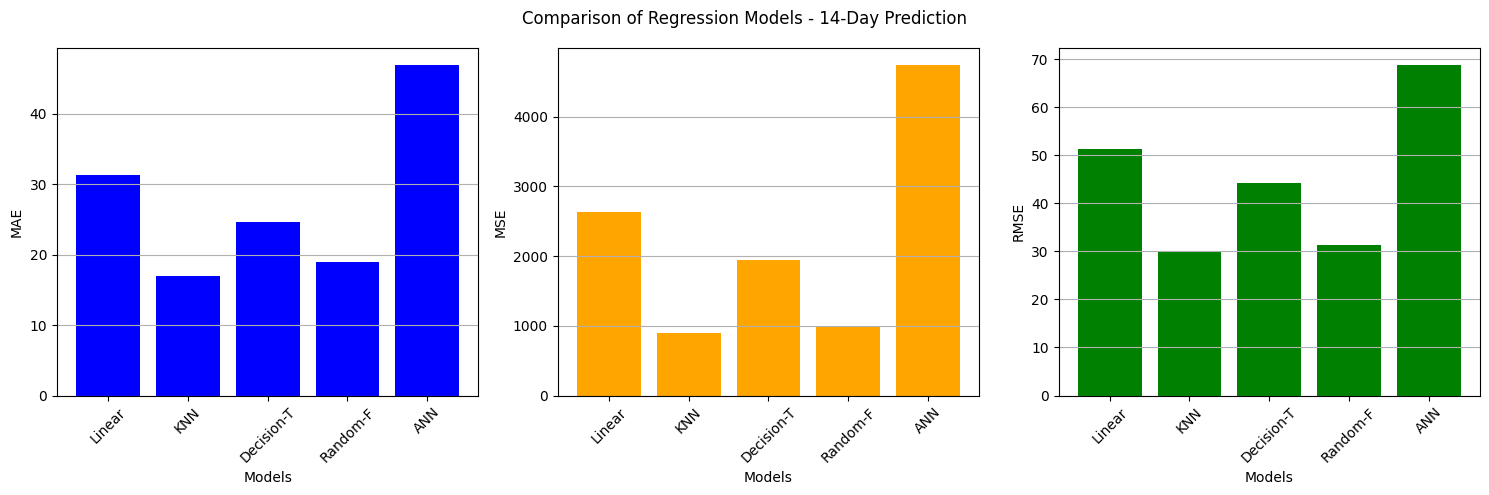

In [15]:
for day in output_days:
    plot_model_evaluation(results[day], day)

In [16]:
for day in output_days:
    save_results_json(
        results[day],
        f"results_{day}day.json"
    )

Saved Sucssesfull! results_1day.json
Saved Sucssesfull! results_7day.json
Saved Sucssesfull! results_14day.json
